# Exercise 1

Create a model using K-Nearest Neigbors to perform classification using the personality dataset.

0 -'introvert'

1 - 'extrovert'

## A. Import libraries

In [ ]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import make_classification

import matplotlib.pyplot as plt

df = pd.read_csv("personality_dataset.csv")


After uploading, your file will be available in the current working directory, and you can then read it with `pd.read_csv('your_uploaded_filename.csv')`.

## B. Load and understand the dataset

Display the first 5 rows of the dataset using `.head()`

In [ ]:
print(df.head())

   Time_spent_Alone Stage_fear  Social_event_attendance  Going_outside  \
0                 3        Yes                        6              7   
1                 2         No                        8              6   
2                 1         No                        9              4   
3                 8         No                        0              0   
4                 5        Yes                        3              0   

  Drained_after_socializing  Friends_circle_size  Post_frequency Personality  
0                        No                   14               5   Extrovert  
1                        No                    7               8   Extrovert  
2                        No                    9               3   Extrovert  
3                       Yes                    9               3   Introvert  
4                        No                    2               6   Introvert  


Display the summary of all the features of the dataset using `.info()`

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Time_spent_Alone           5000 non-null   int64 
 1   Stage_fear                 5000 non-null   object
 2   Social_event_attendance    5000 non-null   int64 
 3   Going_outside              5000 non-null   int64 
 4   Drained_after_socializing  5000 non-null   object
 5   Friends_circle_size        5000 non-null   int64 
 6   Post_frequency             5000 non-null   int64 
 7   Personality                5000 non-null   object
dtypes: int64(5), object(3)
memory usage: 312.6+ KB
None


Display the total number of samples from each label using `.value_counts()`

In [ ]:
print(df["Personality"].value_counts())

Personality
Introvert    2502
Extrovert    2498
Name: count, dtype: int64


Use a histogram to display the number of followers for each samples
 - The x axis should be the number of followers/friends
 - The y axis should be the number of samples in the dataset

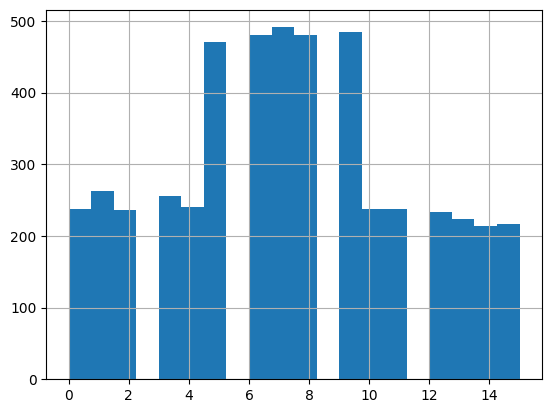

In [ ]:
df["Friends_circle_size"].hist(bins=20)
plt.show()

Remove the name column using `drop()` method

In [ ]:
df = df.drop("name", axis=1)

### Convert categorical features to numerical using `get_dummies`

In [ ]:
df = pd.get_dummies(df, columns=['Stage_fear', 'Drained_after_socializing'], drop_first=True, dtype=int)

print(df.head())

   Time_spent_Alone  Social_event_attendance  Going_outside  \
0                 3                        6              7   
1                 2                        8              6   
2                 1                        9              4   
3                 8                        0              0   
4                 5                        3              0   

   Friends_circle_size  Post_frequency Personality  Stage_fear_Yes  \
0                   14               5   Extrovert               1   
1                    7               8   Extrovert               0   
2                    9               3   Extrovert               0   
3                    9               3   Introvert               0   
4                    2               6   Introvert               1   

   Drained_after_socializing_Yes  
0                              0  
1                              0  
2                              0  
3                              1  
4                        

In [ ]:
X = df.drop("Personality", axis=1).values

y = df["Personality"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3500, 7)
X_test: (1500, 7)
y_train: (3500,)
y_test: (1500,)


df['Stage_fear'] = df['Stage_fear'].map({'Yes': 1, 'No': 0})
df['Drained_after_socializing'] = df['Drained_after_socializing'].map({'Yes': 1, 'No': 0})


## C. Split the dataset into training and test set

The following cells have been moved and consolidated above to ensure `X` and `y` are created from the fully processed DataFrame.

In [ ]:
X = df.drop("Personality", axis=1).values

Convert the labels into an numpy array using `.values()` and store it in a variable "y"

In [ ]:
y = df["Personality"].values

Use `train_test_split()` to split the data.

- Declare a variable `X_train` that will hold the training data
- Declare a variable `X_test` that will hold the test data
- Declare a variable `y_train` that will hold the label of the training data
- Declare a variable `y_test` that will hold the label of the test data


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Display the dimensions of each variables using `.shape()`

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3500, 7)
X_test: (1500, 7)
y_train: (3500,)
y_test: (1500,)


## D. Create the model

Use KNN as a classifier by using `KNeighborsClassifier()`

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)

Train the model using the `.fit()`

In [ ]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

Test the model using the `.predict()`

In [ ]:
y_pred = knn.predict(X_test)

## E. Evaluate the model

Create a confusion matrix

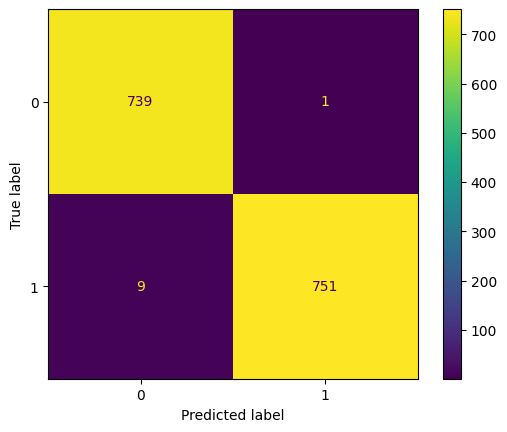

In [ ]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

Display the accuracy

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9933333333333333


Display the precision

In [ ]:

label_mapping = {'Introvert': 0, 'Extrovert': 1}
y_test_encoded = [label_mapping[label] for label in y_test]
y_pred_encoded = [label_mapping[label] for label in y_pred]

print("Precision:", precision_score(y_test_encoded, y_pred_encoded, pos_label=1))

Precision: 0.9879679144385026


Display the recall

In [ ]:

label_mapping = {'Introvert': 0, 'Extrovert': 1}
y_test_encoded = [label_mapping[label] for label in y_test]
y_pred_encoded = [label_mapping[label] for label in y_pred]

print("Recall:", recall_score(y_test_encoded, y_pred_encoded, pos_label=1))

Recall: 0.9986486486486487


Display the f1-score

In [ ]:
label_mapping = {'Introvert': 0, 'Extrovert': 1}
y_test_encoded = [label_mapping[label] for label in y_test]
y_pred_encoded = [label_mapping[label] for label in y_pred]

print("F1 Score:", f1_score(y_test_encoded, y_pred_encoded, pos_label=1))

F1 Score: 0.9932795698924731


## F. Predict your own personality

Enter your own features and use the model to generate a prediction using `.predict()`

In [ ]:

my_features = [[200, 5, 4, 10, 3, 1, 0]]
prediction = knn.predict(my_features)
print("Predicted personality:", "Extrovert" if prediction[0] == 1 else "Introvert")

Predicted personality: Introvert
